# Healthcare Analytics: Understanding Doctor Visit Patterns

This notebook explores the **Doctor Visits** dataset to understand how demographic,
economic, and health-related factors relate to the number of times a patient visits
a doctor. The workflow follows a standard EDA pipeline: load & inspect the data,
clean it up, look at each variable on its own (univariate), then look at how pairs
and groups of variables relate to the target (`visits`).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

## 1. Loading the Data

In [2]:
# NOTE: update this path if your CSV lives somewhere else (e.g. "/content/..." on Colab)
raw = pd.read_csv("Healthcare_Analytics_for_Doctor_Visits.csv")
df = raw.rename(columns={"Unnamed: 0": "patient_id"})
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()

Rows: 5,190  |  Columns: 13


,patient_id,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no


In [3]:
df.sample(5, random_state=42)

,patient_id,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
3690,3691,0,male,0.22,0.06,2,0,1,yes,no,no,no,no
79,80,4,female,0.19,0.15,1,3,0,no,no,no,yes,no
1090,1091,0,female,0.19,0.55,3,0,5,yes,no,no,no,no
1662,1663,0,female,0.27,0.15,1,0,0,no,no,no,no,no
4196,4197,0,male,0.72,1.10,0,0,0,yes,no,no,yes,no


## 2. First Look: Structure & Data Types

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   patient_id  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   str    
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   str    
 9   freepoor    5190 non-null   str    
 10  freerepat   5190 non-null   str    
 11  nchronic    5190 non-null   str    
 12  lchronic    5190 non-null   str    
dtypes: float64(2), int64(5), str(6)
memory usage: 527.2 KB


In [5]:
summary = df.describe(include="all").T
summary

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
patient_id,5190.0,NaN,NaN,NaN,2595.5,1498.368279,1.0,1298.25,2595.5,3892.75,5190.0
visits,5190.0,NaN,NaN,NaN,0.301734,0.798134,0.0,0.0,0.0,0.0,9.0
gender,5190,2,female,2702,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,5190.0,NaN,NaN,NaN,0.406385,0.204782,0.19,0.22,0.32,0.62,0.72
income,5190.0,NaN,NaN,NaN,0.58316,0.368907,0.0,0.25,0.55,0.9,1.5
illness,5190.0,NaN,NaN,NaN,1.431985,1.384152,0.0,0.0,1.0,2.0,5.0
reduced,5190.0,NaN,NaN,NaN,0.86185,2.887628,0.0,0.0,0.0,0.0,14.0
health,5190.0,NaN,NaN,NaN,1.217534,2.124266,0.0,0.0,0.0,2.0,12.0
private,5190,2,no,2892,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freepoor,5190,2,no,4968,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Missing values check

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})

,missing_count,missing_pct
patient_id,0,0.0
visits,0,0.0
gender,0,0.0
age,0,0.0
income,0,0.0
illness,0,0.0
reduced,0,0.0
health,0,0.0
private,0,0.0
freepoor,0,0.0


No missing data anywhere in the dataset, so no imputation is required.

### Duplicate rows check

In [7]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

Duplicate rows: 0


## 3. Univariate Analysis

Looking at each variable in isolation before comparing them against each other.

### 3.1 Gender split

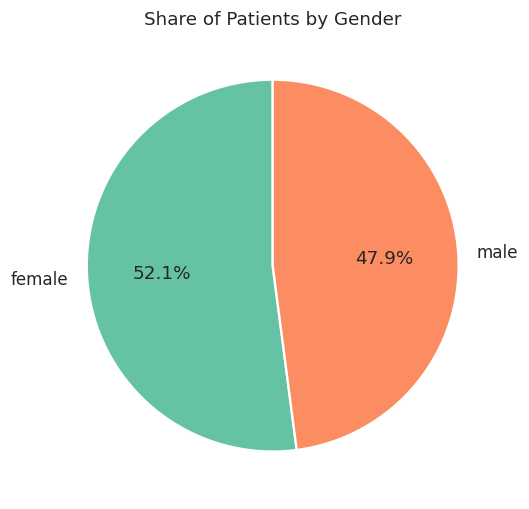

gender
female    2702
male      2488
Name: count, dtype: int64

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))
gender_counts = df["gender"].value_counts()
colors = sns.color_palette("Set2", len(gender_counts))
ax.pie(
    gender_counts.values,
    labels=gender_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax.set_title("Share of Patients by Gender")
plt.tight_layout()
plt.show()

gender_counts

### 3.2 Age distribution

Age summary:


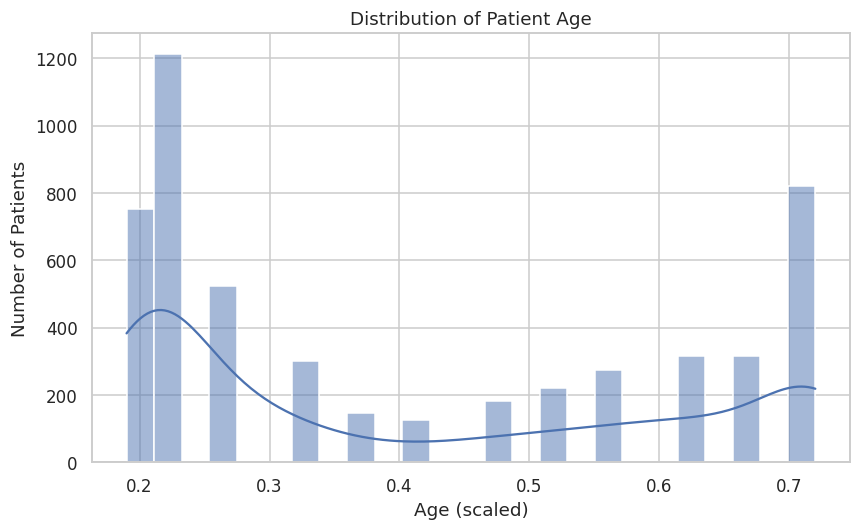

count    5190.000000
mean        0.406385
std         0.204782
min         0.190000
25%         0.220000
50%         0.320000
75%         0.620000
max         0.720000
Name: age, dtype: float64

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["age"], bins=25, kde=True, color="#4C72B0", ax=ax)
ax.set_title("Distribution of Patient Age")
ax.set_xlabel("Age (scaled)")
ax.set_ylabel("Number of Patients")
plt.tight_layout()
plt.show()

print("Age summary:")
df["age"].describe()

### 3.3 Income distribution

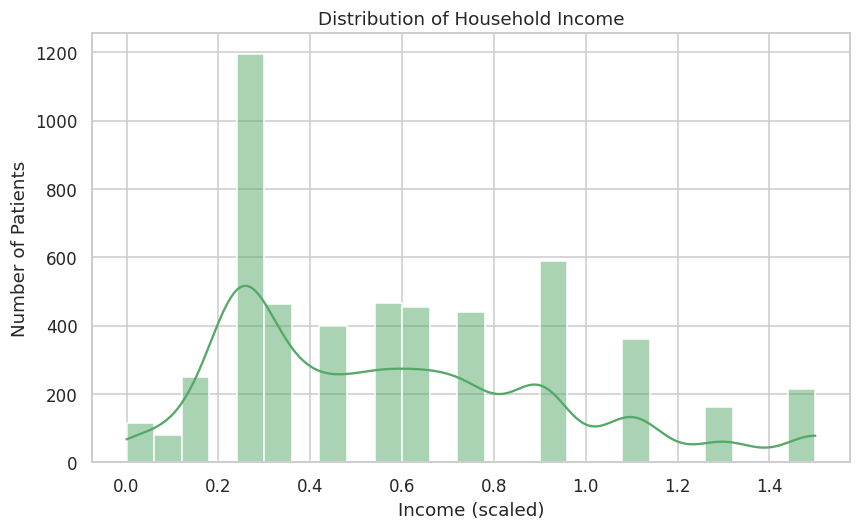

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df["income"], bins=25, kde=True, color="#55A868", ax=ax)
ax.set_title("Distribution of Household Income")
ax.set_xlabel("Income (scaled)")
ax.set_ylabel("Number of Patients")
plt.tight_layout()
plt.show()

### 3.4 Number of doctor visits

Median visits: 0.0  |  Mean visits: 0.30


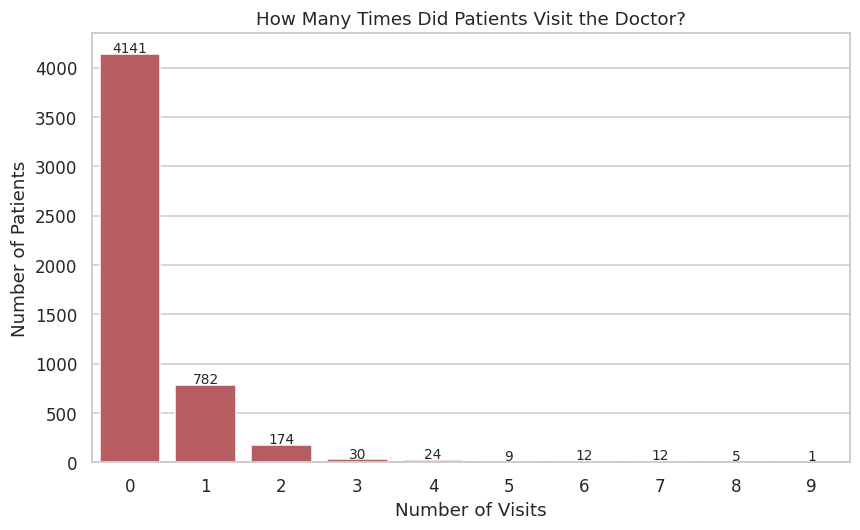

In [11]:
visit_counts = df["visits"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=visit_counts.index, y=visit_counts.values, color="#C44E52", ax=ax)
ax.set_title("How Many Times Did Patients Visit the Doctor?")
ax.set_xlabel("Number of Visits")
ax.set_ylabel("Number of Patients")
for i, v in enumerate(visit_counts.values):
    ax.text(i, v + 15, str(v), ha="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Median visits: {df['visits'].median()}  |  Mean visits: {df['visits'].mean():.2f}")

### 3.5 Illness score and chronic condition flags

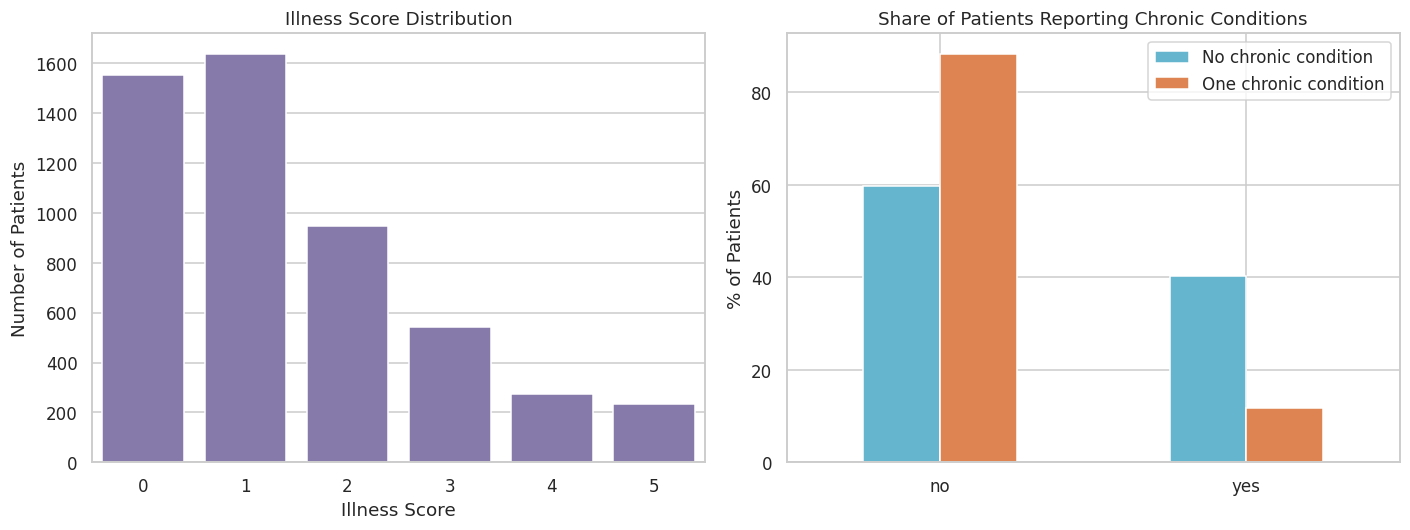

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.countplot(x="illness", data=df, color="#8172B2", ax=axes[0])
axes[0].set_title("Illness Score Distribution")
axes[0].set_xlabel("Illness Score")
axes[0].set_ylabel("Number of Patients")

chronic_share = pd.DataFrame({
    "No chronic condition": df["nchronic"].value_counts(normalize=True) * 100,
    "One chronic condition": df["lchronic"].value_counts(normalize=True) * 100,
})
chronic_share.plot(kind="bar", ax=axes[1], color=["#64B5CD", "#DD8452"])
axes[1].set_title("Share of Patients Reporting Chronic Conditions")
axes[1].set_ylabel("% of Patients")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="")

plt.tight_layout()
plt.show()

## 4. Bivariate Analysis

Now we compare `visits` against the other variables to look for patterns.

### 4.1 Average visits by gender

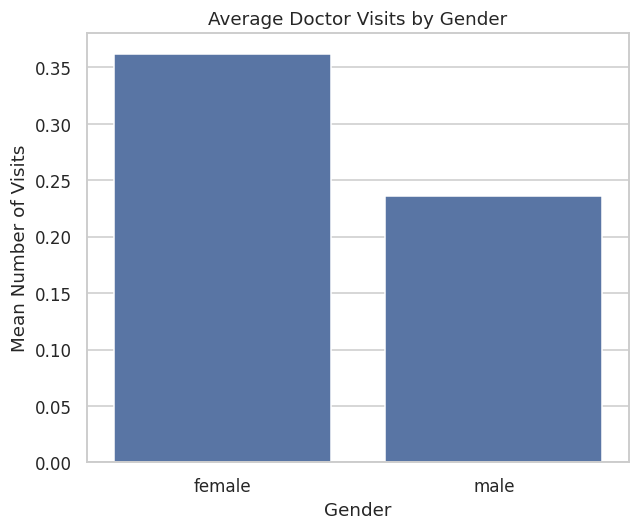

,count,mean_visits,median_visits
gender,,,
female,2702,0.361954,0.0
male,2488,0.236334,0.0


In [13]:
gender_visits = df.pivot_table(index="gender", values="visits", aggfunc=["count", "mean", "median"])
gender_visits.columns = ["count", "mean_visits", "median_visits"]
display(gender_visits)

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(x=gender_visits.index, y=gender_visits["mean_visits"], color="#4C72B0", ax=ax)
ax.set_title("Average Doctor Visits by Gender")
ax.set_xlabel("Gender")
ax.set_ylabel("Mean Number of Visits")
plt.tight_layout()
plt.show()

### 4.2 Average visits by insurance status

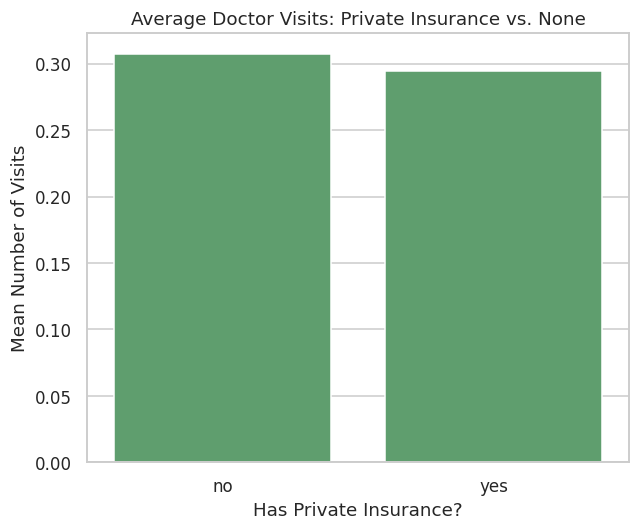

private
no     0.307400
yes    0.294604
Name: visits, dtype: float64

In [14]:
insurance_visits = df.groupby("private")["visits"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 5))
sns.barplot(x=insurance_visits.index, y=insurance_visits.values, color="#55A868", ax=ax)
ax.set_title("Average Doctor Visits: Private Insurance vs. None")
ax.set_xlabel("Has Private Insurance?")
ax.set_ylabel("Mean Number of Visits")
plt.tight_layout()
plt.show()

insurance_visits

### 4.3 Illness score vs. doctor visits

Correlation (illness, visits): 0.224


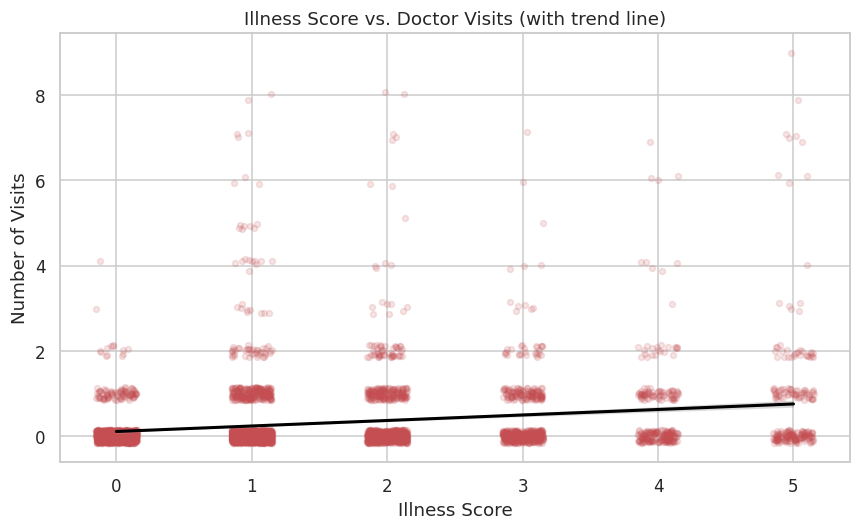

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(
    x="illness", y="visits", data=df,
    x_jitter=0.15, y_jitter=0.15,
    scatter_kws={"alpha": 0.15, "color": "#C44E52", "s": 15},
    line_kws={"color": "black", "linewidth": 2},
    ax=ax,
)
ax.set_title("Illness Score vs. Doctor Visits (with trend line)")
ax.set_xlabel("Illness Score")
ax.set_ylabel("Number of Visits")
plt.tight_layout()
plt.show()

print("Correlation (illness, visits):", round(df["illness"].corr(df["visits"]), 3))

### 4.4 Correlation among numeric variables

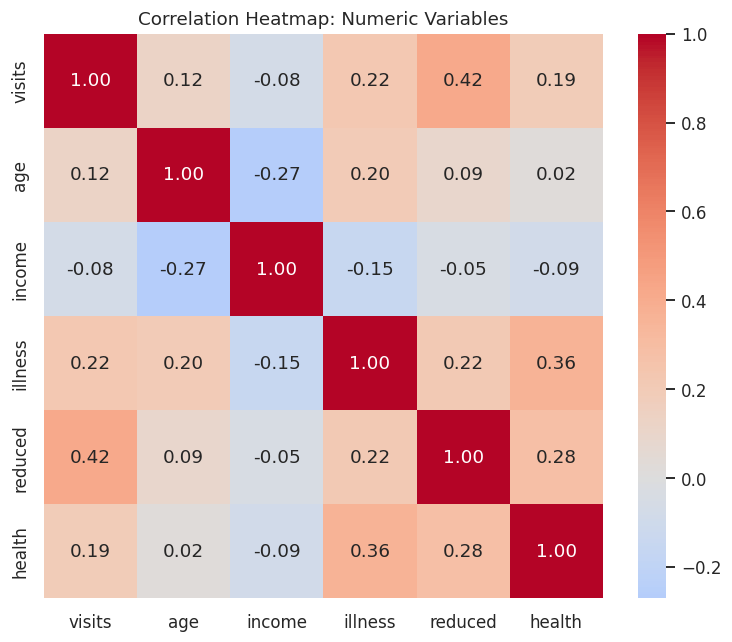

In [16]:
numeric_cols = ["visits", "age", "income", "illness", "reduced", "health"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Heatmap: Numeric Variables")
plt.tight_layout()
plt.show()

## 5. Multivariate Analysis

Combining two or more factors at once to see whether relationships change across
subgroups.

### 5.1 Visits by chronic condition and gender

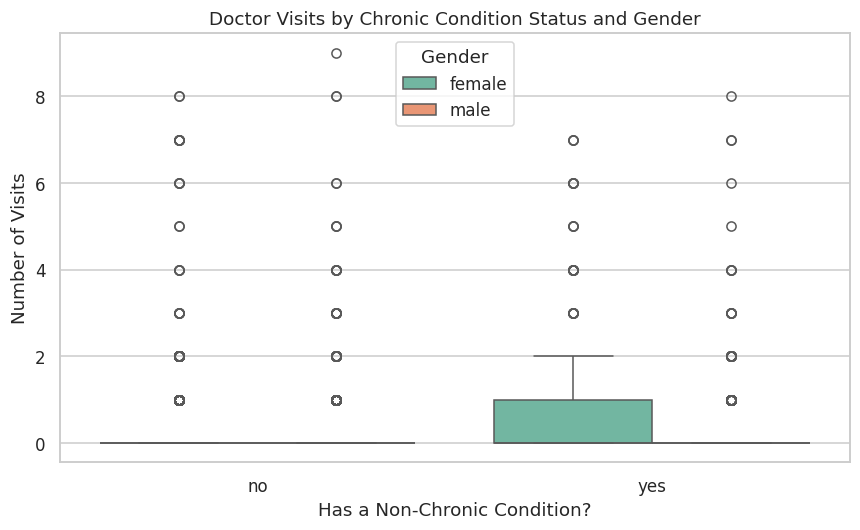

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x="nchronic", y="visits", hue="gender", data=df, ax=ax)
ax.set_title("Doctor Visits by Chronic Condition Status and Gender")
ax.set_xlabel("Has a Non-Chronic Condition?")
ax.set_ylabel("Number of Visits")
ax.legend(title="Gender")
plt.tight_layout()
plt.show()

### 5.2 Age vs. visits, colored by insurance status

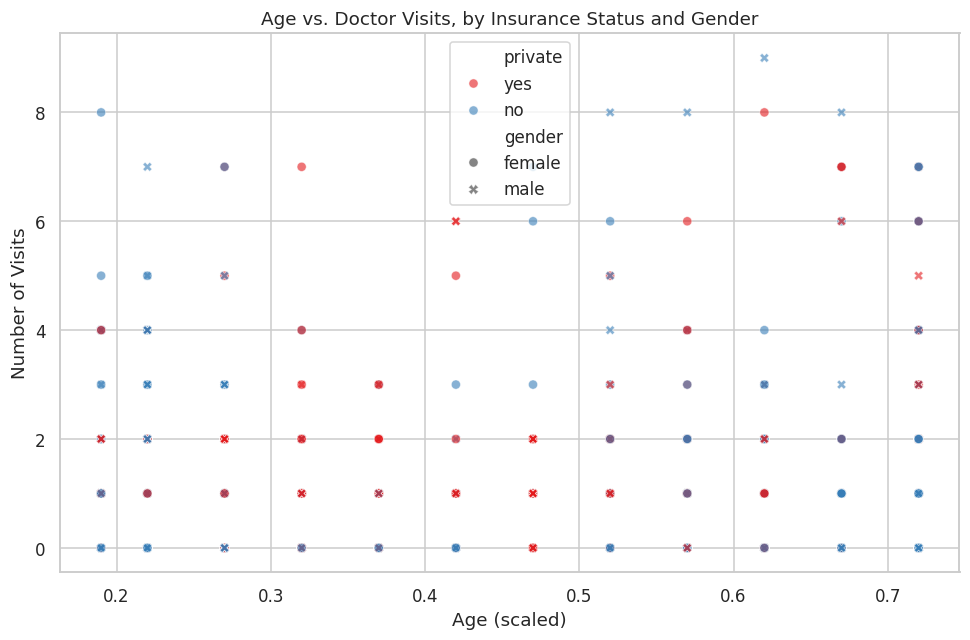

In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    x="age", y="visits", hue="private", style="gender",
    data=df, alpha=0.6, palette="Set1", ax=ax,
)
ax.set_title("Age vs. Doctor Visits, by Insurance Status and Gender")
ax.set_xlabel("Age (scaled)")
ax.set_ylabel("Number of Visits")
plt.tight_layout()
plt.show()

### 5.3 Average visits across income quartiles and illness levels

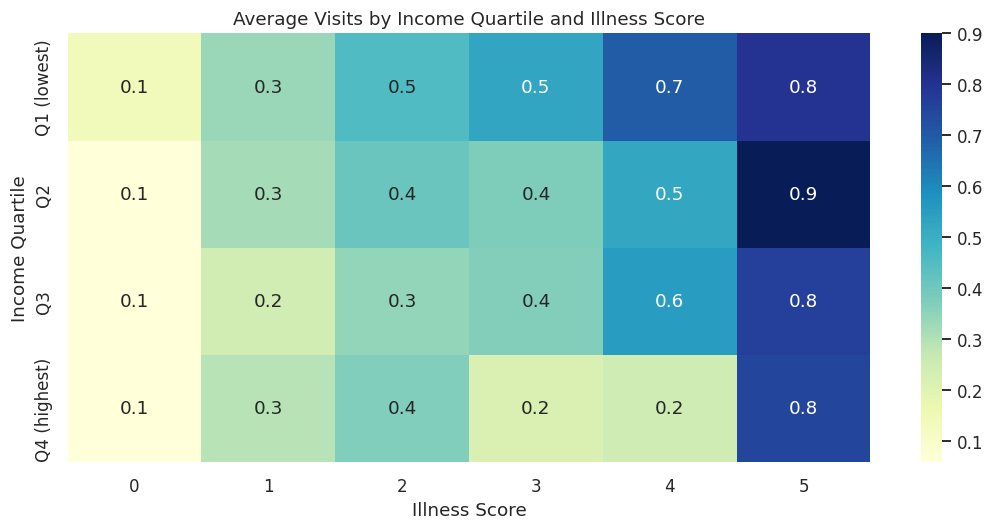

In [19]:
df["income_quartile"] = pd.qcut(df["income"], 4, labels=["Q1 (lowest)", "Q2", "Q3", "Q4 (highest)"])
pivot = df.pivot_table(index="income_quartile", columns="illness", values="visits", aggfunc="mean")

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu", ax=ax)
ax.set_title("Average Visits by Income Quartile and Illness Score")
ax.set_xlabel("Illness Score")
ax.set_ylabel("Income Quartile")
plt.tight_layout()
plt.show()

## 6. Key Takeaways

- The dataset is clean: **no missing values and no duplicate rows** across 5,190 patient records.
- **Illness score has the strongest relationship with doctor visits** of the numeric
  variables examined, which matches intuition — sicker patients visit the doctor more often.
- Patients **with private insurance tend to average more visits** than those without,
  suggesting insurance coverage may reduce a barrier to seeking care.
- **Gender differences in average visits are modest**, though the spread (variance) differs
  slightly between groups.
- Combining **income and illness** shows that higher illness scores drive up visit counts
  across every income quartile, but the effect is not perfectly uniform — worth a deeper
  statistical test (e.g. ANOVA or a Poisson regression on `visits`) as a next step.